### importing libraries

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import talib              
import quantstats as qs   
import os
import certifi

# Force curl (used by yfinance/pynance) to use Python's trusted CA certificates
os.environ['CURL_CA_BUNDLE'] = certifi.where()

# Now import the rest of your libraries
import pynance as py
import yfinance as yf

# Make plots a bit nicer
plt.style.use("seaborn-v0_8")
plt.rcParams["figure.figsize"] = (12, 6)

### Load Data

In [41]:
# Load stock data
df = pd.read_csv(r"C:\Users\Administrator\Downloads\challenge-week1\challenge-week1\data\AAPL.csv")

# Convert date column to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Set datetime as index
df = df.set_index('Date')

df.head()


,Close,High,Low,Open,Volume
Date,,,,,
2009-01-02,2.721686,2.730385,2.554037,2.575630,746015200
2009-01-05,2.836553,2.884539,2.780469,2.794266,1181608400
2009-01-06,2.789767,2.914229,2.770872,2.877641,1289310400
2009-01-07,2.729484,2.774170,2.706990,2.753477,753048800
2009-01-08,2.780169,2.793666,2.700393,2.712090,673500800


### Calculate Technical Indicators (TA-Lib)

#### Simple Moving Average (SMA)

In [42]:
df['SMA_20'] = talib.SMA(df['Close'], timeperiod=20)
df['SMA_50'] = talib.SMA(df['Close'], timeperiod=50)

#### Exponential Moving Average (EMA)

In [43]:
df['EMA_20'] = talib.EMA(df['Close'], timeperiod=20)

#### Relative Strength Index (RSI)

In [44]:
df['RSI_14'] = talib.RSI(df['Close'], timeperiod=14)

#### MACD

In [45]:
df['MACD'], df['MACD_signal'], df['MACD_hist'] = talib.MACD(
    df['Close'], 
    fastperiod=12, 
    slowperiod=26, 
    signalperiod=9
)


#### Bollinger Bands

In [46]:
df['BB_upper'], df['BB_middle'], df['BB_lower'] = talib.BBANDS(
    df['Close'], 
    timeperiod=20, 
    nbdevup=2, 
    nbdevdn=2
)


### Visualizations

#### Plot Close Price + SMA / EMA

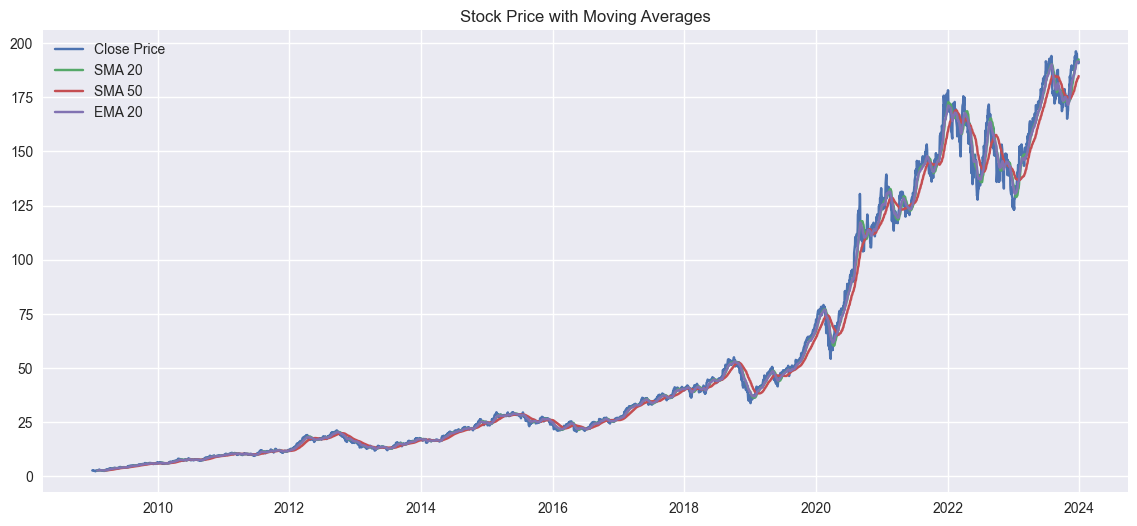

In [47]:
plt.figure(figsize=(14,6))
plt.plot(df['Close'], label='Close Price')
plt.plot(df['SMA_20'], label='SMA 20')
plt.plot(df['SMA_50'], label='SMA 50')
plt.plot(df['EMA_20'], label='EMA 20')
plt.title("Stock Price with Moving Averages")
plt.legend()
plt.show()


#### RSI Plot

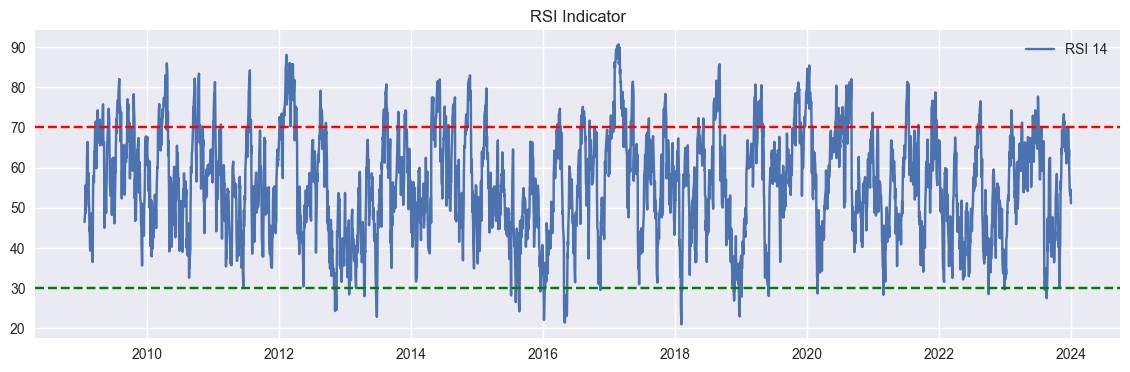

In [48]:
plt.figure(figsize=(14,4))
plt.plot(df['RSI_14'], label='RSI 14')
plt.axhline(70, color='red', linestyle='--')
plt.axhline(30, color='green', linestyle='--')
plt.title("RSI Indicator")
plt.legend()
plt.show()


#### MACD Plot

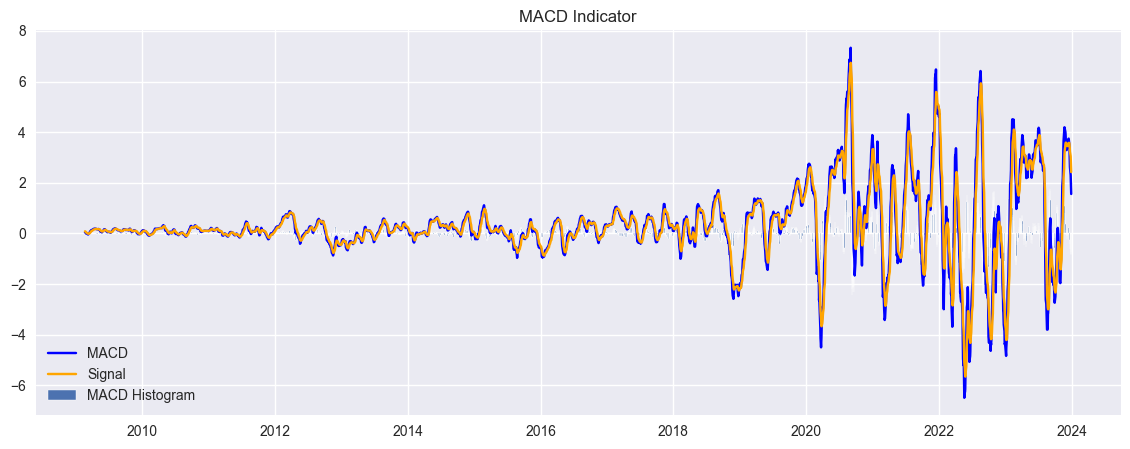

In [49]:
plt.figure(figsize=(14,5))
plt.plot(df['MACD'], label='MACD', color='blue')
plt.plot(df['MACD_signal'], label='Signal', color='orange')
plt.bar(df.index, df['MACD_hist'], label='MACD Histogram')
plt.title("MACD Indicator")
plt.legend()
plt.show()


#### Bollinger Bands

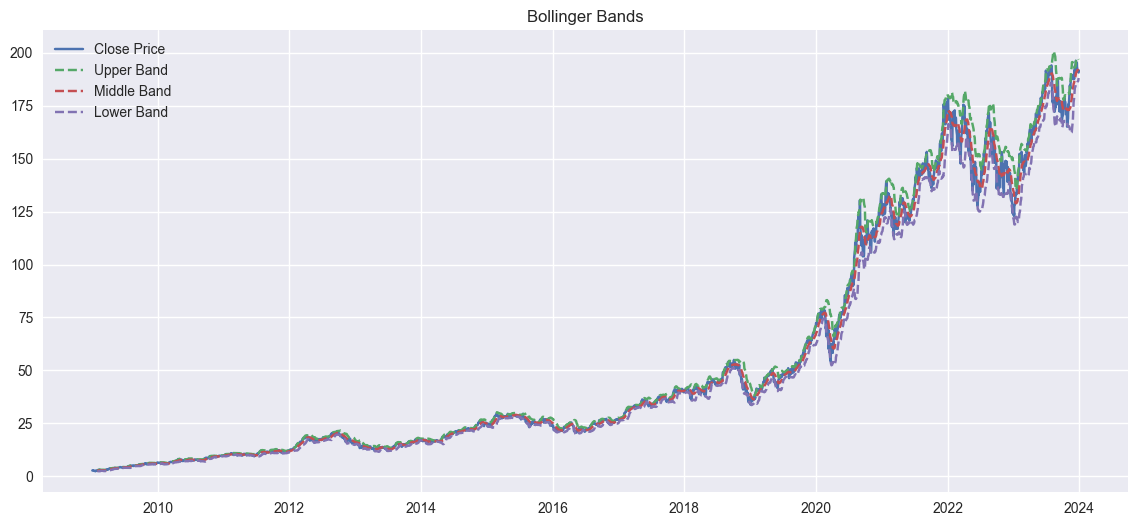

In [50]:
plt.figure(figsize=(14,6))
plt.plot(df['Close'], label='Close Price')
plt.plot(df['BB_upper'], label='Upper Band', linestyle='--')
plt.plot(df['BB_middle'], label='Middle Band', linestyle='--')
plt.plot(df['BB_lower'], label='Lower Band', linestyle='--')
plt.title("Bollinger Bands")
plt.legend()
plt.show()


### Quick look at price and volume

              count          mean           std           min           25%  \
Close        3774.0  5.384117e+01  5.506404e+01  2.345299e+00  1.505036e+01   
High         3774.0  5.438380e+01  5.562723e+01  2.459265e+00  1.518304e+01   
Low          3774.0  5.324746e+01  5.444013e+01  2.345299e+00  1.490189e+01   
Open         3774.0  5.380163e+01  5.500918e+01  2.380989e+00  1.500758e+01   
Volume       3774.0  2.640640e+08  2.345629e+08  2.404830e+07  9.581845e+07   
SMA_20       3755.0  5.361919e+01  5.464405e+01  2.661195e+00  1.493000e+01   
SMA_50       3725.0  5.328468e+01  5.401923e+01  2.733174e+00  1.505395e+01   
EMA_20       3755.0  5.362256e+01  5.462505e+01  2.662455e+00  1.487482e+01   
RSI_14       3760.0  5.601626e+01  1.293286e+01  2.103003e+01  4.647875e+01   
MACD         3741.0  3.491322e-01  1.477349e+00 -6.488947e+00 -8.494414e-02   
MACD_signal  3741.0  3.466404e-01  1.386567e+00 -5.653254e+00 -8.148312e-02   
MACD_hist    3741.0  2.491754e-03  4.520531e-01 -2.4

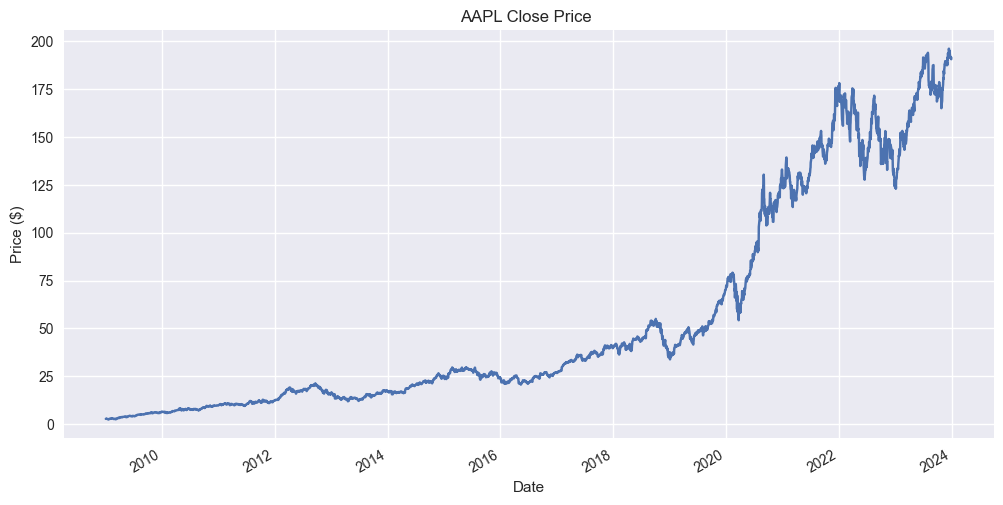

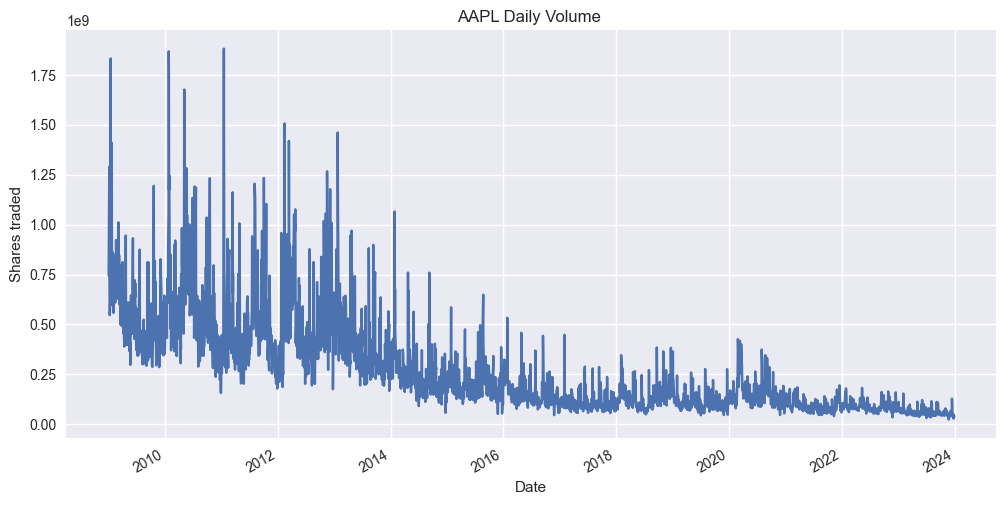

In [51]:
print(df.describe().T)

# Close price chart
df["Close"].plot(title="AAPL Close Price ")
plt.ylabel("Price ($)")
plt.show()

# Volume chart
df["Volume"].plot(title="AAPL Daily Volume ")
plt.ylabel("Shares traded")
plt.show()


### Compute technical indicators with TA-Lib

In [52]:
# Use 'Adj Close' if available, otherwise 'Close'
if "Adj Close" in df.columns:
    price = df["Adj Close"]
else:
    price = df["Close"]

# --- Moving Averages ---
df["SMA_20"] = talib.SMA(price, timeperiod=20)
df["SMA_50"] = talib.SMA(price, timeperiod=50)
df["EMA_20"] = talib.EMA(price, timeperiod=20)

# --- RSI ---
df["RSI_14"] = talib.RSI(price, timeperiod=14)

# --- MACD ---
df["MACD"], df["MACD_signal"], df["MACD_hist"] = talib.MACD(
    price, fastperiod=12, slowperiod=26, signalperiod=9
)


df.tail()


,Close,High,Low,Open,Volume,SMA_20,SMA_50,EMA_20,RSI_14,MACD,MACD_signal,MACD_hist,BB_upper,BB_middle,BB_lower
Date,,,,,,,,,,,,,,,
2023-12-22,191.788757,193.581821,191.164647,193.353962,37149600,191.856618,183.572859,191.510231,54.672784,2.633141,3.235256,-0.602115,197.478146,191.856618,186.235090
2023-12-26,191.243912,192.076049,191.025969,191.798670,28919300,192.018094,183.858864,191.484867,53.090049,2.304751,3.049155,-0.744404,197.367843,192.018094,186.668345
2023-12-27,191.342972,191.689703,189.302247,190.689158,48087700,192.154308,184.149424,191.471353,53.354446,2.029104,2.845145,-0.816041,197.285152,192.154308,187.023465
2023-12-28,191.768951,192.838849,191.362784,192.323710,34049900,192.362839,184.479567,191.499696,54.540999,1.823998,2.640915,-0.816918,197.056446,192.362839,187.669231
2023-12-29,190.728775,192.581275,189.936256,192.085953,42672100,192.490633,184.814828,191.426275,51.121347,1.559539,2.424640,-0.865101,196.848102,192.490633,188.133164


### Price + SMA + Bollinger Bands

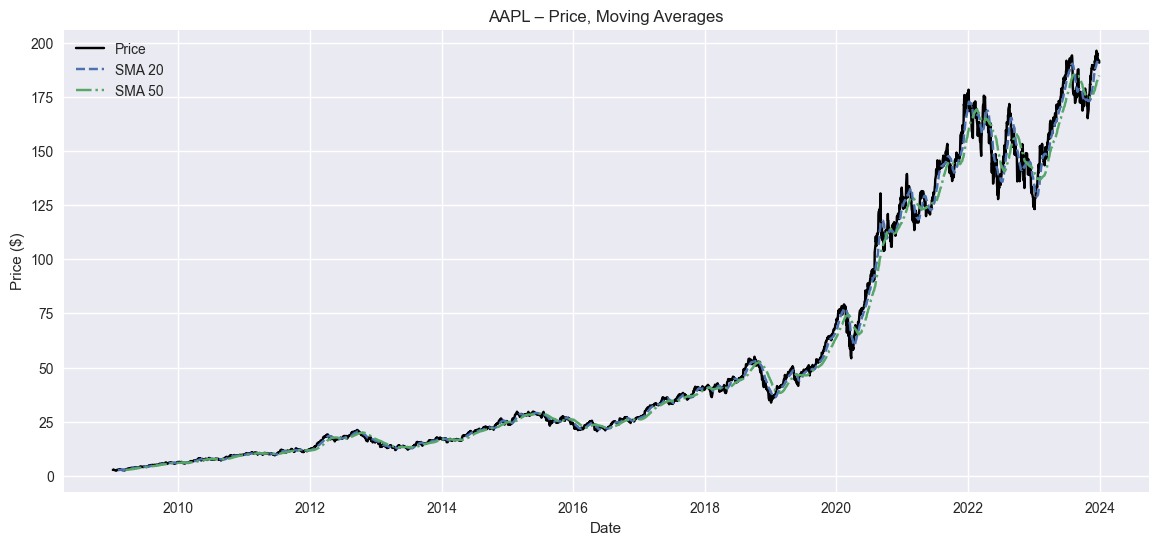

In [53]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(df.index, price, label="Price", color="black")
ax.plot(df.index, df["SMA_20"], label="SMA 20", linestyle="--")
ax.plot(df.index, df["SMA_50"], label="SMA 50", linestyle="-.")


ax.set_title("AAPL – Price, Moving Averages")
ax.set_xlabel("Date")
ax.set_ylabel("Price ($)")
ax.legend()
plt.show()


### RSI – Overbought / Oversold

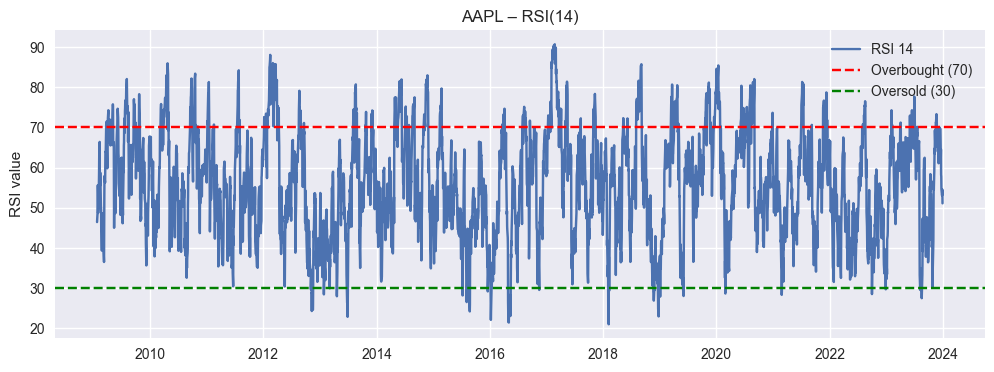

In [54]:
fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(df.index, df["RSI_14"], label="RSI 14")
ax.axhline(70, color="red", linestyle="--", label="Overbought (70)")
ax.axhline(30, color="green", linestyle="--", label="Oversold (30)")

ax.set_title("AAPL – RSI(14)")
ax.set_ylabel("RSI value")
ax.legend()
plt.show()


### MACD – Trend & momentum

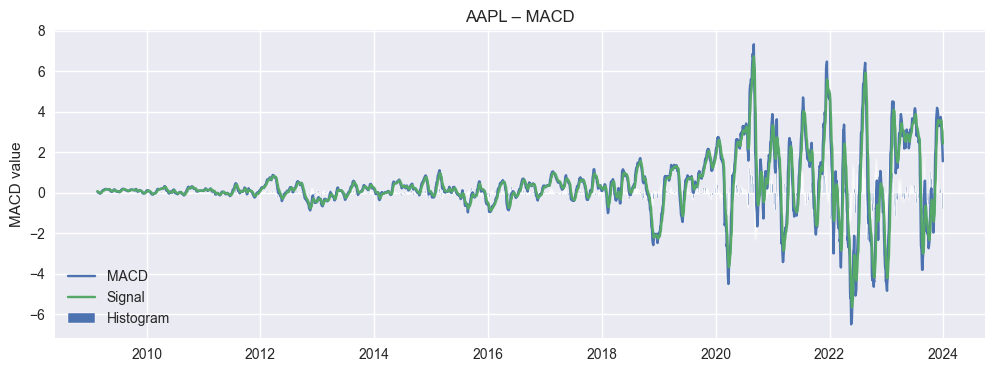

In [55]:
fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(df.index, df["MACD"], label="MACD")
ax.plot(df.index, df["MACD_signal"], label="Signal")
ax.bar(df.index, df["MACD_hist"], label="Histogram")

ax.set_title("AAPL – MACD")
ax.set_ylabel("MACD value")
ax.legend()
plt.show()
